In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## Question 1: FFT of Functions

### Question 1(a): Square Function

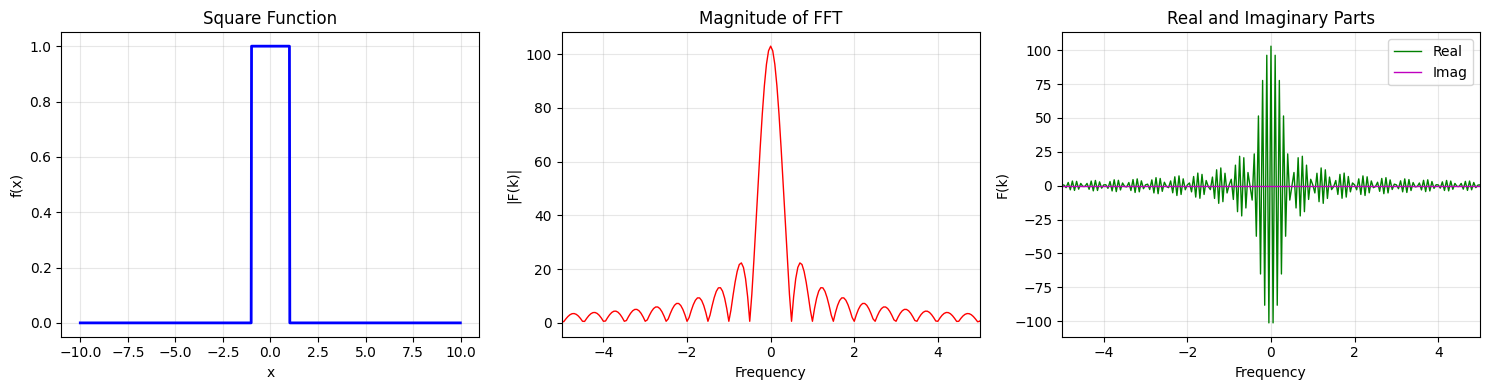

Square function width: 2.0
FFT shows sinc-like pattern, as expected for rect function


In [2]:
N = 1024
L = 20.0
x = np.linspace(-L/2, L/2, N, endpoint=False)
dx = L / N

width = 2.0
square = np.zeros(N)
mask = np.abs(x) <= width/2
square[mask] = 1.0

fft_square = np.fft.fft(square)
fft_square_shifted = np.fft.fftshift(fft_square)
freqs = np.fft.fftfreq(N, d=dx)
freqs_shifted = np.fft.fftshift(freqs)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(x, square, 'b-', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Square Function')
ax1.grid(alpha=0.3)

ax2.plot(freqs_shifted, np.abs(fft_square_shifted), 'r-', linewidth=1)
ax2.set_xlabel('Frequency')
ax2.set_ylabel('|F(k)|')
ax2.set_title('Magnitude of FFT')
ax2.set_xlim(-5, 5)
ax2.grid(alpha=0.3)

ax3.plot(freqs_shifted, np.real(fft_square_shifted), 'g-', linewidth=1, label='Real')
ax3.plot(freqs_shifted, np.imag(fft_square_shifted), 'm-', linewidth=1, label='Imag')
ax3.set_xlabel('Frequency')
ax3.set_ylabel('F(k)')
ax3.set_title('Real and Imaginary Parts')
ax3.set_xlim(-5, 5)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Square function width: {width}")
print(f"FFT shows sinc-like pattern, as expected for rect function")

### Question 1(b): Double Slit

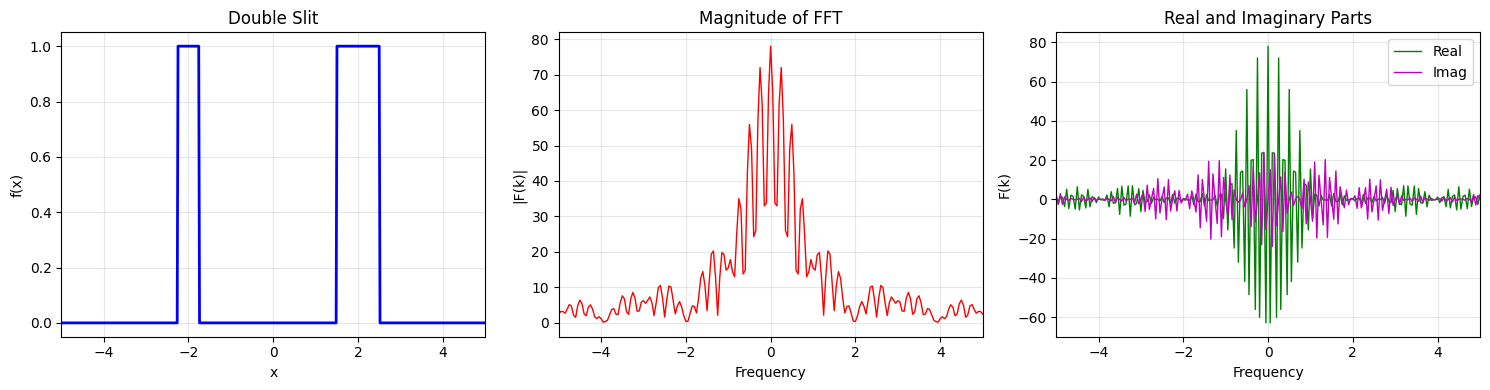

Slit 1: center=-2.0, width=0.5
Slit 2: center=2.0, width=1.0
FFT shows interference pattern from two slits


In [3]:
N = 1024
L = 20.0
x = np.linspace(-L/2, L/2, N, endpoint=False)
dx = L / N

slit1_center = -2.0
slit1_width = 0.5
slit2_center = 2.0
slit2_width = 1.0

double_slit = np.zeros(N)
mask1 = np.abs(x - slit1_center) <= slit1_width/2
mask2 = np.abs(x - slit2_center) <= slit2_width/2
double_slit[mask1] = 1.0
double_slit[mask2] = 1.0

fft_double = np.fft.fft(double_slit)
fft_double_shifted = np.fft.fftshift(fft_double)
freqs = np.fft.fftfreq(N, d=dx)
freqs_shifted = np.fft.fftshift(freqs)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(x, double_slit, 'b-', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Double Slit')
ax1.set_xlim(-5, 5)
ax1.grid(alpha=0.3)

ax2.plot(freqs_shifted, np.abs(fft_double_shifted), 'r-', linewidth=1)
ax2.set_xlabel('Frequency')
ax2.set_ylabel('|F(k)|')
ax2.set_title('Magnitude of FFT')
ax2.set_xlim(-5, 5)
ax2.grid(alpha=0.3)

ax3.plot(freqs_shifted, np.real(fft_double_shifted), 'g-', linewidth=1, label='Real')
ax3.plot(freqs_shifted, np.imag(fft_double_shifted), 'm-', linewidth=1, label='Imag')
ax3.set_xlabel('Frequency')
ax3.set_ylabel('F(k)')
ax3.set_title('Real and Imaginary Parts')
ax3.set_xlim(-5, 5)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Slit 1: center={slit1_center}, width={slit1_width}")
print(f"Slit 2: center={slit2_center}, width={slit2_width}")
print(f"FFT shows interference pattern from two slits")

## Question 2: Time-Dependent Schrödinger Equation

In [4]:
def split_operator_step(psi, V, dt, k_vals, hbar=1.0, m=1.0):
    psi_k = np.fft.fft(psi)
    E_kin = (hbar**2 * k_vals**2) / (2.0 * m)
    psi_k *= np.exp(-0.5j * E_kin * dt / hbar)
    psi = np.fft.ifft(psi_k)
    
    psi *= np.exp(-1j * V * dt / hbar)
    
    psi_k = np.fft.fft(psi)
    psi_k *= np.exp(-0.5j * E_kin * dt / hbar)
    psi = np.fft.ifft(psi_k)
    
    return psi

def initial_gaussian(x, x0, sigma):
    norm = 1.0 / (sigma * np.sqrt(2 * np.pi))
    return np.sqrt(norm) * np.exp(-(x - x0)**2 / (2 * sigma**2))

### Question 2(a): Potential Barrier

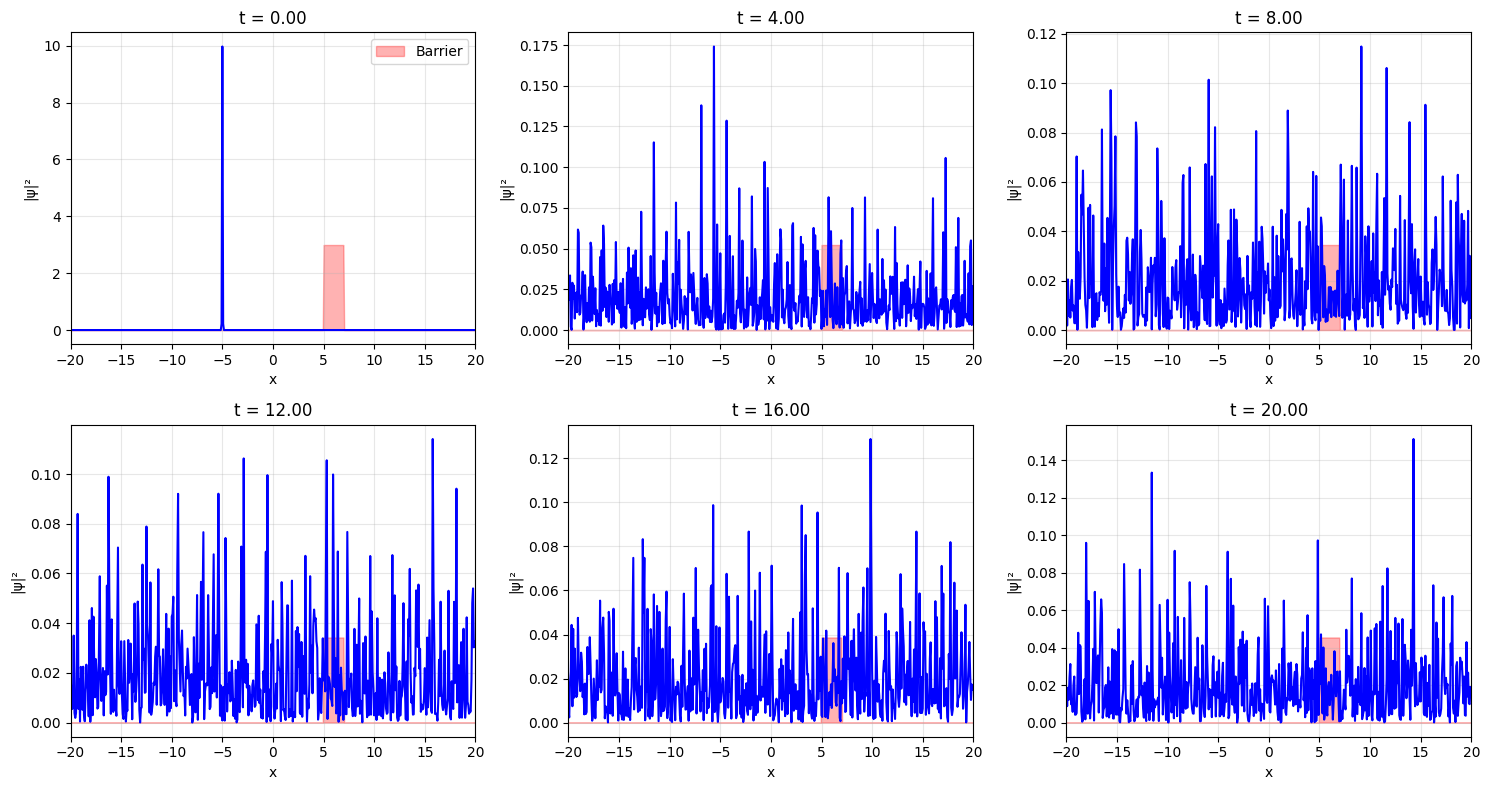


Barrier: V0 = 40.0, from x = 5.0 to 7.0
Transmitted probability: 0.2704
Reflected probability: 0.5069
Total (check): 0.7773


In [7]:
hbar = 1.0
m = 1.0
Nx = 512
x_min = -20.0
x_max = 20.0
L = x_max - x_min
dx = L / Nx

x = np.linspace(x_min, x_max, Nx, endpoint=False)
k_vals = np.fft.fftfreq(Nx, d=dx) * 2.0 * np.pi

V0 = 40.0
barrier_left = 5.0
barrier_right = 7.0
V = np.zeros(Nx)
mask = (x >= barrier_left) & (x <= barrier_right)
V[mask] = V0

x0 = -5.0
sigma = 0.04
k0 = 5.0  # or 3.0 for harmonic oscillator
psi = initial_gaussian(x, x0, sigma) * np.exp(1j * k0 * x)

dt = 0.01
n_steps = 2000
plot_every = 50

snapshots = [psi.copy()]
times = [0]

for step in range(1, n_steps + 1):
    psi = split_operator_step(psi, V, dt, k_vals, hbar, m)
    if step % plot_every == 0:
        snapshots.append(psi.copy())
        times.append(step * dt)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_indices = [0, len(snapshots)//5, 2*len(snapshots)//5, 
                3*len(snapshots)//5, 4*len(snapshots)//5, -1]

for idx, ax in enumerate(axes.flat):
    snap_idx = plot_indices[idx]
    prob = np.abs(snapshots[snap_idx])**2
    ax.plot(x, prob, 'b-', linewidth=1.5)
    ax.fill_between(x, 0, V/V0 * np.max(prob) * 0.3, 
                     alpha=0.3, color='red', label='Barrier')
    ax.set_xlabel('x')
    ax.set_ylabel('|ψ|²')
    ax.set_title(f't = {times[snap_idx]:.2f}')
    ax.set_xlim(x_min, x_max)
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

transmitted = np.sum(np.abs(snapshots[-1][x > barrier_right])**2) * dx
reflected = np.sum(np.abs(snapshots[-1][x < barrier_left])**2) * dx
print(f"\nBarrier: V0 = {V0}, from x = {barrier_left} to {barrier_right}")
print(f"Transmitted probability: {transmitted:.4f}")
print(f"Reflected probability: {reflected:.4f}")
print(f"Total (check): {transmitted + reflected:.4f}")

### Question 2(b): Harmonic Potential

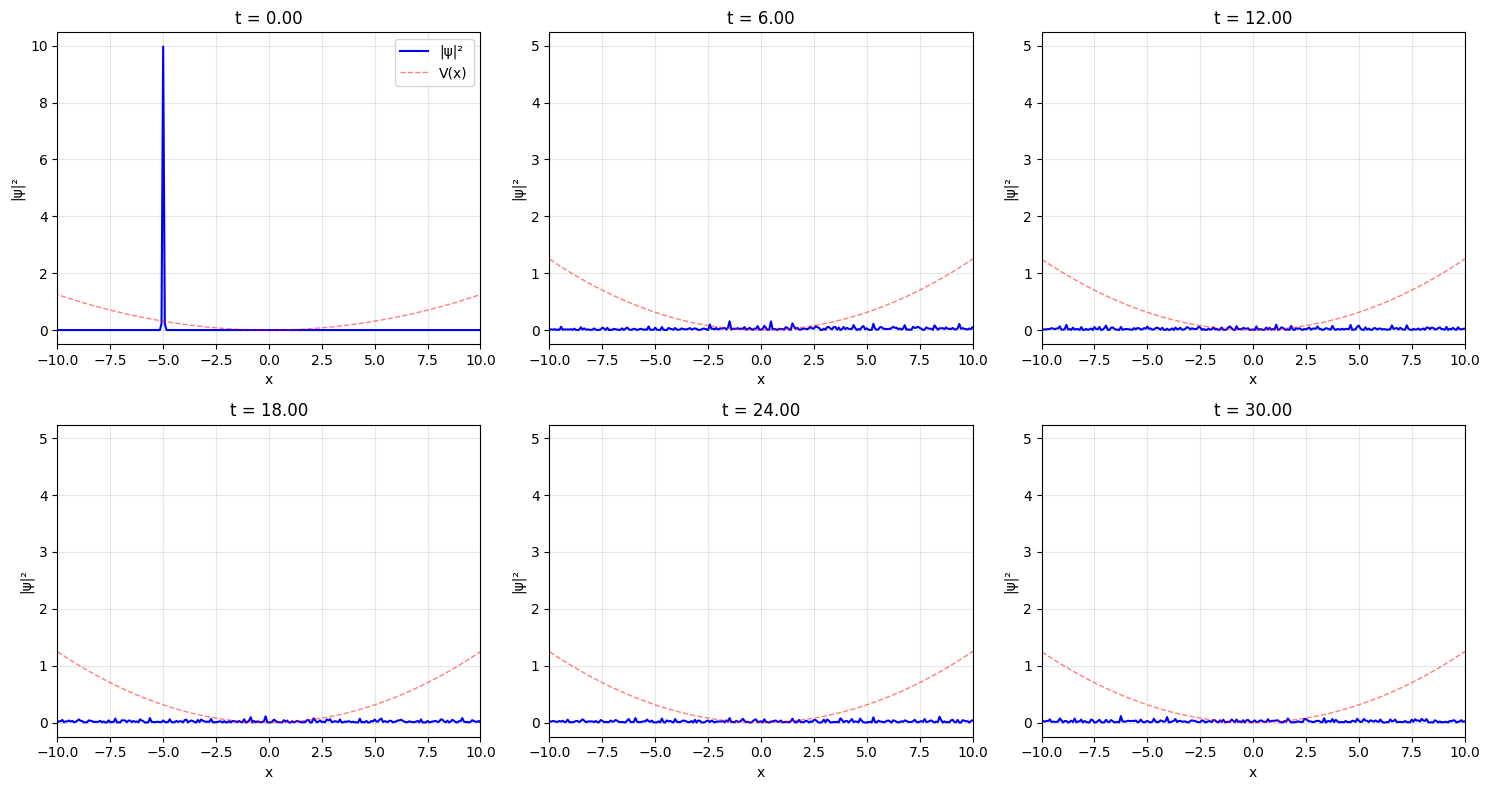

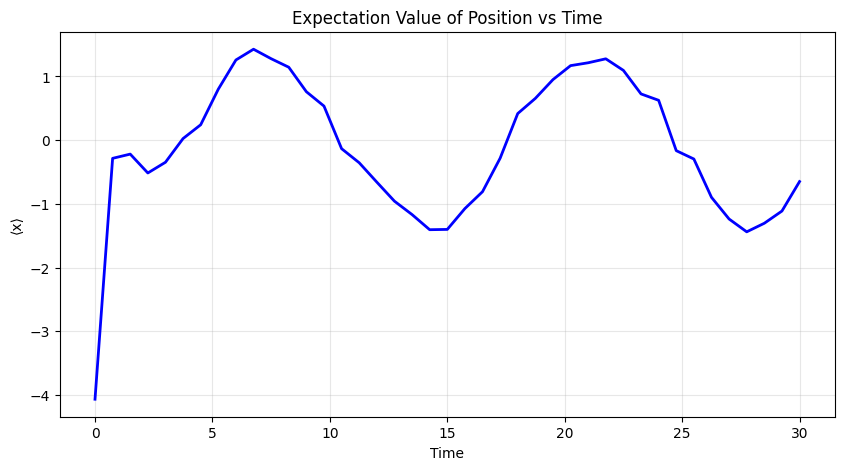


Harmonic potential: V(x) = 0.1 × x²
Initial position: x0 = -5.0
Wavepacket oscillates in the potential well


In [8]:
hbar = 1.0
m = 1.0
Nx = 512
x_min = -20.0
x_max = 20.0
L = x_max - x_min
dx = L / Nx

x = np.linspace(x_min, x_max, Nx, endpoint=False)
k_vals = np.fft.fftfreq(Nx, d=dx) * 2.0 * np.pi

V = 0.1 * x**2

x0 = -5.0
sigma = 0.04
psi = initial_gaussian(x, x0, sigma)

dt = 0.01
n_steps = 3000
plot_every = 75

snapshots = [psi.copy()]
times = [0]
expectation_x = [np.sum(x * np.abs(psi)**2) * dx]

for step in range(1, n_steps + 1):
    psi = split_operator_step(psi, V, dt, k_vals, hbar, m)
    if step % plot_every == 0:
        snapshots.append(psi.copy())
        times.append(step * dt)
        expectation_x.append(np.sum(x * np.abs(psi)**2) * dx)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_indices = [0, len(snapshots)//5, 2*len(snapshots)//5, 
                3*len(snapshots)//5, 4*len(snapshots)//5, -1]

V_normalized = V / np.max(V) * np.max(np.abs(snapshots[0])**2) * 0.5

for idx, ax in enumerate(axes.flat):
    snap_idx = plot_indices[idx]
    prob = np.abs(snapshots[snap_idx])**2
    ax.plot(x, prob, 'b-', linewidth=1.5, label='|ψ|²')
    ax.plot(x, V_normalized, 'r--', alpha=0.5, linewidth=1, label='V(x)')
    ax.set_xlabel('x')
    ax.set_ylabel('|ψ|²')
    ax.set_title(f't = {times[snap_idx]:.2f}')
    ax.set_xlim(-10, 10)
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(times, expectation_x, 'b-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('⟨x⟩')
plt.title('Expectation Value of Position vs Time')
plt.grid(alpha=0.3)
plt.show()

print(f"\nHarmonic potential: V(x) = 0.1 × x²")
print(f"Initial position: x0 = {x0}")
print(f"Wavepacket oscillates in the potential well")